# 🤖 Machine Learning Model Training for Insider Trading Alpha Prediction

## Approach: Classification (Not Regression)

**Why Classification?** Initial regression experiments yielded R² as low as -17, indicating that predicting exact return values from insider trading data is infeasible due to:
1. **Extreme outliers** (100%+ returns distort the loss function)
2. **Low signal-to-noise ratio** in financial data
3. **Random market movements** dominating short-term returns

**New Strategy:** Instead of predicting exact alpha values, we classify trades as:
- `1` = "High Probability Trade" (alpha > 5%)
- `0` = "Skip" (alpha ≤ 5%)

## Key Design Decisions
- **Target**: Binary classification (`alpha_3m > 0.05`)
- **Metric**: ROC-AUC and Precision (not Accuracy)
- **Validation**: Time-series split (Train: 2018-2023, Test: 2024+)
- **Outlier Handling**: Already capped in data pipeline (returns -100%/+300%, alpha -150%/+200%)
- **Features**: 12 numerical + 1 categorical (sector)

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    precision_recall_curve, roc_curve, average_precision_score,
    precision_score, recall_score, f1_score
)
from sklearn.calibration import calibration_curve

# Gradient Boosting Classifiers
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Hyperparameter Tuning
import optuna
from optuna.samplers import TPESampler

# Feature Importance
import shap

# Visualization
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
%matplotlib inline

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(" Libraries imported successfully")

 Libraries imported successfully


---
## Part 1: Data Loading & Target Engineering

The data is already cleaned in the processing pipeline (outliers capped). We convert to binary classification.

In [2]:
# Load the ML-ready dataset
project_root = Path.cwd().parent.parent
data_path = project_root / "data" / "processed" / "insider_trades_ml_ready.parquet"

df = pd.read_parquet(data_path)

print(f" Dataset loaded:")
print(f"   Shape: {df.shape}")
print(f"   Date range: {df['filing_date'].min().date()} to {df['filing_date'].max().date()}")
print(f"\n Alpha_3m statistics (raw):")
print(df['alpha_3m'].describe())

 Dataset loaded:
   Shape: (42015, 23)
   Date range: 2018-01-02 to 2026-02-02

 Alpha_3m statistics (raw):
count    39393.000000
mean         0.020920
std          0.353319
min         -1.135053
25%         -0.149511
50%         -0.013127
75%          0.124027
max          3.000000
Name: alpha_3m, dtype: float64


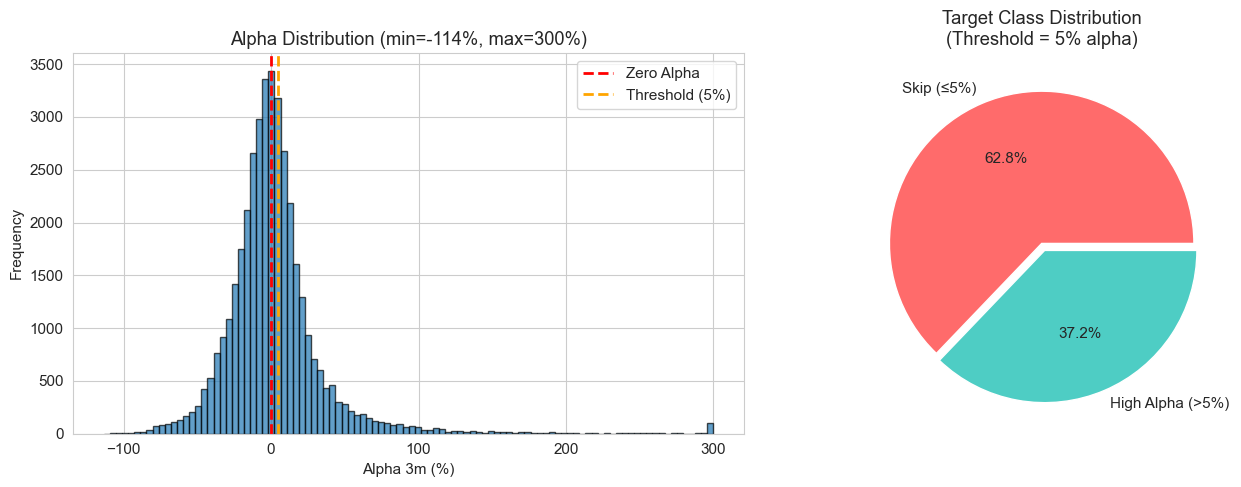

  Alpha Statistics:
   Mean:   2.09%
   Median: -1.31%
   Std:    35.33%
   Range:  [-114%, 300%] (already capped in pipeline)


In [3]:
# Visualize the alpha distribution 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Alpha distribution (already capped: -150% to +300%)
alpha_raw = df['alpha_3m'].dropna() * 100
axes[0].hist(alpha_raw, bins=100, edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Alpha')
axes[0].axvline(5, color='orange', linestyle='--', linewidth=2, label='Threshold (5%)')
axes[0].set_xlabel('Alpha 3m (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Alpha Distribution (min={alpha_raw.min():.0f}%, max={alpha_raw.max():.0f}%)')
axes[0].legend()

# Class distribution preview
class_preview = (df['alpha_3m'].dropna() > 0.05).value_counts()
colors = ['#ff6b6b', '#4ecdc4']  # Red for Skip, Green for High Alpha
axes[1].pie(class_preview.values, labels=['Skip (≤5%)', 'High Alpha (>5%)'], 
            autopct='%1.1f%%', colors=colors, explode=(0, 0.05))
axes[1].set_title(f'Target Class Distribution\n(Threshold = 5% alpha)')

plt.tight_layout()
plt.show()

print(f"  Alpha Statistics:")
print(f"   Mean:   {alpha_raw.mean():.2f}%")
print(f"   Median: {alpha_raw.median():.2f}%")
print(f"   Std:    {alpha_raw.std():.2f}%")
print(f"   Range:  [{alpha_raw.min():.0f}%, {alpha_raw.max():.0f}%] (already capped in pipeline)")

### 1.1 Target Engineering (The Pivot)

In [4]:
print(" Engineering target variable...\n")

# Create binary classification target
ALPHA_THRESHOLD = 0.05  # 5% alpha threshold
df['target_class'] = (df['alpha_3m'] > ALPHA_THRESHOLD).astype(int)

# Filter to rows with valid alpha_3m
valid_target_mask = df['alpha_3m'].notna()
df_model = df[valid_target_mask].copy()

# Analyze class distribution
class_dist = df_model['target_class'].value_counts(normalize=True)
positive_rate = class_dist.get(1, 0) * 100

print(f" Target Class Distribution:")
print(f"   Class 0 (Skip):        {class_dist.get(0, 0)*100:.1f}%")
print(f"   Class 1 (High Alpha):  {positive_rate:.1f}%")
print(f"   Total samples:         {len(df_model):,}")

# Calculate class weight for imbalanced data
if positive_rate < 30:
    scale_pos_weight = (100 - positive_rate) / positive_rate
    print(f"\n Imbalanced classes! Using scale_pos_weight = {scale_pos_weight:.2f}")
else:
    scale_pos_weight = 1.0
    print(f"\n Classes are reasonably balanced")

 Engineering target variable...

 Target Class Distribution:
   Class 0 (Skip):        62.8%
   Class 1 (High Alpha):  37.2%
   Total samples:         39,393

 Classes are reasonably balanced


### 1.2 Missing Value Imputation

In [5]:
print("🔧 Imputing missing values...\n")

# 1. Impute missing `sector` with "Unknown"
sector_missing_before = df_model['sector'].isna().sum()
df_model['sector'] = df_model['sector'].fillna('Unknown')
print(f" sector: Filled {sector_missing_before:,} NaN values with 'Unknown'")

# 2. Impute missing `price_range_position` with 0.5 (neutral)
prp_missing_before = df_model['price_range_position'].isna().sum()
df_model['price_range_position'] = df_model['price_range_position'].fillna(0.5)
print(f" price_range_position: Filled {prp_missing_before:,} NaN values with 0.5")

# 3. Impute missing `volatility_30d` with median
vol_missing_before = df_model['volatility_30d'].isna().sum()
vol_median = df_model['volatility_30d'].median()
df_model['volatility_30d'] = df_model['volatility_30d'].fillna(vol_median)
print(f" volatility_30d: Filled {vol_missing_before:,} NaN values with median ({vol_median:.4f})")

# 4. Impute missing `days_since_last_trade` with -1 (flag for first-time trades)
dslt_missing_before = df_model['days_since_last_trade'].isna().sum()
df_model['days_since_last_trade'] = df_model['days_since_last_trade'].fillna(-1)
print(f" days_since_last_trade: Filled {dslt_missing_before:,} NaN values with -1")

# 5. Impute any remaining numeric columns with median
for col in df_model.select_dtypes(include=[np.number]).columns:
    missing = df_model[col].isna().sum()
    if missing > 0:
        df_model[col] = df_model[col].fillna(df_model[col].median())
        print(f" {col}: Filled {missing:,} NaN values with median")

print(f"\n Final dataset shape: {df_model.shape}")

🔧 Imputing missing values...

 sector: Filled 8,162 NaN values with 'Unknown'
 price_range_position: Filled 86 NaN values with 0.5
 volatility_30d: Filled 1,260 NaN values with median (0.5429)
 days_since_last_trade: Filled 10,643 NaN values with -1
 return_1w: Filled 1 NaN values with median
 return_1m: Filled 4 NaN values with median
 alpha_1w: Filled 1 NaN values with median
 alpha_1m: Filled 4 NaN values with median

 Final dataset shape: (39393, 24)


### 1.3 Feature Selection

In [6]:
# Define columns by category
METADATA_COLS = ['ticker', 'filing_date', 'insider_id']  # Keep for backtesting only

LEAKAGE_COLS = [
    'alpha_1w', 'alpha_1m', 'alpha_3m',  # Future returns (leakage!)
    'return_1w', 'return_1m', 'return_3m',  # Raw future returns
    'benchmark_used',  # Metadata
    'target_class'  # Our target
]

# Numerical features - core insider trading signals
NUMERICAL_COLS = [
    'role_bucket',              # Insider role importance (CEO=4, Director=1)
    'log_transaction_value',    # Size of the trade
    'delta_owned',              # Change in ownership
    'owned_pct_change',         # Percentage change in holdings
    'insider_trade_count',      # Insider's historical trade count
    'days_since_last_trade',    # Time since last trade
    'reporting_lag',            # Days between trade and filing
    'cluster_buy',              # Number of insiders buying same day
    'cluster_c_level_pct',      # % of C-level in cluster
    'log_market_cap',           # Company size
    'price_range_position',     # Price within 52-week range
    'volatility_30d'            # Recent stock volatility
]

# Categorical features
CATEGORICAL_COLS = ['sector']

# Verify all columns exist
available_numerical = [col for col in NUMERICAL_COLS if col in df_model.columns]
missing_cols = [col for col in NUMERICAL_COLS if col not in df_model.columns]

if missing_cols:
    print(f"  Missing numerical columns: {missing_cols}")
    NUMERICAL_COLS = available_numerical

FEATURE_COLS = NUMERICAL_COLS + CATEGORICAL_COLS

print(f" Feature Configuration:")
print(f"   Numerical features: {len(NUMERICAL_COLS)}")
print(f"   Categorical features: {len(CATEGORICAL_COLS)}")
print(f"   Total features: {len(FEATURE_COLS)}")
print(f"\n Features: {FEATURE_COLS}")

 Feature Configuration:
   Numerical features: 12
   Categorical features: 1
   Total features: 13

 Features: ['role_bucket', 'log_transaction_value', 'delta_owned', 'owned_pct_change', 'insider_trade_count', 'days_since_last_trade', 'reporting_lag', 'cluster_buy', 'cluster_c_level_pct', 'log_market_cap', 'price_range_position', 'volatility_30d', 'sector']


---
## Part 2: Time-Series Train/Test Split

**Critical**: Temporal split to avoid look-ahead bias.

In [7]:
# Define temporal split
TRAIN_END_DATE = '2023-12-31'
TEST_START_DATE = '2024-01-01'

# Ensure filing_date is datetime
df_model['filing_date'] = pd.to_datetime(df_model['filing_date'])

# Split data temporally
train_mask = df_model['filing_date'] <= TRAIN_END_DATE
test_mask = df_model['filing_date'] >= TEST_START_DATE

df_train = df_model[train_mask].copy()
df_test = df_model[test_mask].copy()

print(f" Temporal Split:")
print(f"   Train: {df_train['filing_date'].min().date()} to {df_train['filing_date'].max().date()}")
print(f"   Test:  {df_test['filing_date'].min().date()} to {df_test['filing_date'].max().date()}")
print(f"\n Dataset sizes:")
print(f"   Train: {len(df_train):,} rows ({100*len(df_train)/len(df_model):.1f}%)")
print(f"   Test:  {len(df_test):,} rows ({100*len(df_test)/len(df_model):.1f}%)")

print(f"\n Class distribution:")
print(f"   Train - Class 1: {df_train['target_class'].mean()*100:.1f}%")
print(f"   Test  - Class 1: {df_test['target_class'].mean()*100:.1f}%")

 Temporal Split:
   Train: 2018-01-02 to 2023-12-29
   Test:  2024-01-02 to 2025-11-06

 Dataset sizes:
   Train: 31,620 rows (80.3%)
   Test:  7,773 rows (19.7%)

 Class distribution:
   Train - Class 1: 37.8%
   Test  - Class 1: 34.4%


In [8]:
# Encode categorical variables
print("🔧 Encoding categorical variables...\n")

# Label encode sector
le_sector = LabelEncoder()
df_train['sector_encoded'] = le_sector.fit_transform(df_train['sector'])
df_test['sector_encoded'] = le_sector.transform(df_test['sector'].apply(
    lambda x: x if x in le_sector.classes_ else 'Unknown'
))

# Feature columns for encoded data
FEATURE_COLS_ENCODED = NUMERICAL_COLS + ['sector_encoded']

print(f" Sector encoded: {len(le_sector.classes_)} unique values")

🔧 Encoding categorical variables...

 Sector encoded: 13 unique values


In [9]:
# Prepare X and y
X_train = df_train[FEATURE_COLS_ENCODED].copy()
y_train = df_train['target_class'].copy()

X_test = df_test[FEATURE_COLS_ENCODED].copy()
y_test = df_test['target_class'].copy()

# Keep metadata and actual alpha for backtesting
test_metadata = df_test[['ticker', 'filing_date', 'alpha_3m', 'target_class']].copy()

print(f" Data prepared for training:")
print(f"   X_train: {X_train.shape}")
print(f"   X_test:  {X_test.shape}")
print(f"   y_train class balance: {y_train.mean()*100:.1f}% positive")
print(f"   y_test class balance:  {y_test.mean()*100:.1f}% positive")

 Data prepared for training:
   X_train: (31620, 13)
   X_test:  (7773, 13)
   y_train class balance: 37.8% positive
   y_test class balance:  34.4% positive


---
## Part 3: XGBoost Classifier with Optuna Tuning

**Key changes for classification:**
- Lower learning rate (0.01-0.1) for stability
- Higher regularization (reg_alpha, reg_lambda)
- Shallower trees (max_depth 3-5)
- Optimize for ROC-AUC

In [10]:
def objective_xgb_clf(trial):
    """
    Optuna objective for XGBoost Classifier.
    Optimizes for ROC-AUC with time-series cross-validation.
    """
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 6),  # Shallower!
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),  # Lower!
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 20),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 10.0, log=True),  # Higher L1!
        'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 50.0, log=True),  # Higher L2!
        'scale_pos_weight': scale_pos_weight,  # Handle imbalance
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'verbosity': 0,
        'eval_metric': 'auc'
    }
    
    # Time-series cross-validation
    tscv = TimeSeriesSplit(n_splits=3)
    auc_scores = []
    
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model = xgb.XGBClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        
        y_pred_proba = model.predict_proba(X_val)[:, 1]
        auc_scores.append(roc_auc_score(y_val, y_pred_proba))
    
    return np.mean(auc_scores)

In [11]:
# Run Optuna optimization
print("🔍 Running Optuna Hyperparameter Tuning for XGBoost Classifier...")
print("   Optimizing for ROC-AUC...\n")

optuna.logging.set_verbosity(optuna.logging.WARNING)

study_xgb = optuna.create_study(
    direction='maximize',  # Maximize AUC
    sampler=TPESampler(seed=RANDOM_STATE)
)

study_xgb.optimize(objective_xgb_clf, n_trials=50, show_progress_bar=True)

print(f"\n XGBoost Optimization Complete:")
print(f"   Best AUC (CV): {study_xgb.best_value:.4f}")
print(f"   Best Params: {study_xgb.best_params}")

🔍 Running Optuna Hyperparameter Tuning for XGBoost Classifier...
   Optimizing for ROC-AUC...



  0%|          | 0/50 [00:00<?, ?it/s]


 XGBoost Optimization Complete:
   Best AUC (CV): 0.5794
   Best Params: {'n_estimators': 409, 'max_depth': 5, 'learning_rate': 0.016783269694489924, 'subsample': 0.70371990381836, 'colsample_bytree': 0.859792428913356, 'min_child_weight': 15, 'reg_alpha': 3.9297910733137806, 'reg_lambda': 44.750323544619874}


In [12]:
# Train final XGBoost model
best_params_xgb = study_xgb.best_params
best_params_xgb['random_state'] = RANDOM_STATE
best_params_xgb['n_jobs'] = -1
best_params_xgb['scale_pos_weight'] = scale_pos_weight

xgb_model = xgb.XGBClassifier(**best_params_xgb)
xgb_model.fit(X_train, y_train)

# Predict on test set
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Metrics
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
ap_xgb = average_precision_score(y_test, y_pred_proba_xgb)

print(f"🔹 XGBoost Classifier (Tuned):")
print(f"   ROC-AUC: {auc_xgb:.4f}")
print(f"   Avg Precision: {ap_xgb:.4f}")
print(f"\n{classification_report(y_test, y_pred_xgb, target_names=['Skip', 'High Alpha'])}")

🔹 XGBoost Classifier (Tuned):
   ROC-AUC: 0.5613
   Avg Precision: 0.3857

              precision    recall  f1-score   support

        Skip       0.66      0.93      0.77      5099
  High Alpha       0.42      0.10      0.16      2674

    accuracy                           0.64      7773
   macro avg       0.54      0.51      0.47      7773
weighted avg       0.58      0.64      0.56      7773



---
## Part 4: CatBoost Classifier with Optuna Tuning

In [14]:
# CatBoost with native categorical handling
FEATURE_COLS_CAT = NUMERICAL_COLS + ['sector']

X_train_cat = df_train[FEATURE_COLS_CAT].copy()
X_test_cat = df_test[FEATURE_COLS_CAT].copy()

cat_features = ['sector']

print(f" CatBoost with native categorical handling")
print(f"   Features: {len(FEATURE_COLS_CAT)}")

 CatBoost with native categorical handling
   Features: 13


In [15]:
def objective_catboost_clf(trial):
    """
    Optuna objective for CatBoost Classifier.
    """
    params = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'depth': trial.suggest_int('depth', 3, 6),  # Shallow trees
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 50.0, log=True),
        'border_count': trial.suggest_int('border_count', 32, 128),
        'auto_class_weights': 'Balanced',  # Handle imbalance
        'random_seed': RANDOM_STATE,
        'verbose': False
    }
    
    tscv = TimeSeriesSplit(n_splits=3)
    auc_scores = []
    
    for train_idx, val_idx in tscv.split(X_train_cat):
        X_tr = X_train_cat.iloc[train_idx]
        X_val = X_train_cat.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model = CatBoostClassifier(**params)
        model.fit(X_tr, y_tr, cat_features=cat_features, eval_set=(X_val, y_val), verbose=False)
        
        y_pred_proba = model.predict_proba(X_val)[:, 1]
        auc_scores.append(roc_auc_score(y_val, y_pred_proba))
    
    return np.mean(auc_scores)

In [16]:
# Run Optuna optimization
print(" Running Optuna Hyperparameter Tuning for CatBoost Classifier...")

study_cat = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=RANDOM_STATE)
)

study_cat.optimize(objective_catboost_clf, n_trials=50, show_progress_bar=True)

print(f"\n CatBoost Optimization Complete:")
print(f"   Best AUC (CV): {study_cat.best_value:.4f}")
print(f"   Best Params: {study_cat.best_params}")

 Running Optuna Hyperparameter Tuning for CatBoost Classifier...


  0%|          | 0/50 [00:00<?, ?it/s]


 CatBoost Optimization Complete:
   Best AUC (CV): 0.5864
   Best Params: {'iterations': 391, 'depth': 6, 'learning_rate': 0.05749956050687109, 'l2_leaf_reg': 24.140696623194327, 'border_count': 55}


In [17]:
# Train final CatBoost model
best_params_cat = study_cat.best_params
best_params_cat['random_seed'] = RANDOM_STATE
best_params_cat['verbose'] = False
best_params_cat['auto_class_weights'] = 'Balanced'

cat_model = CatBoostClassifier(**best_params_cat)
cat_model.fit(X_train_cat, y_train, cat_features=cat_features)

# Predict on test set
y_pred_cat = cat_model.predict(X_test_cat)
y_pred_proba_cat = cat_model.predict_proba(X_test_cat)[:, 1]

# Metrics
auc_cat = roc_auc_score(y_test, y_pred_proba_cat)
ap_cat = average_precision_score(y_test, y_pred_proba_cat)

print(f" CatBoost Classifier (Tuned):")
print(f"   ROC-AUC: {auc_cat:.4f}")
print(f"   Avg Precision: {ap_cat:.4f}")
print(f"\n{classification_report(y_test, y_pred_cat, target_names=['Skip', 'High Alpha'])}")

 CatBoost Classifier (Tuned):
   ROC-AUC: 0.5601
   Avg Precision: 0.3858

              precision    recall  f1-score   support

        Skip       0.70      0.45      0.55      5099
  High Alpha       0.38      0.64      0.48      2674

    accuracy                           0.52      7773
   macro avg       0.54      0.54      0.51      7773
weighted avg       0.59      0.52      0.52      7773



---
## Part 5: LightGBM Classifier with Optuna Tuning

In [18]:
def objective_lgb_clf(trial):
    """
    Optuna objective for LightGBM Classifier.
    """
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 10, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 50.0, log=True),
        'class_weight': 'balanced',
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'verbose': -1
    }
    
    tscv = TimeSeriesSplit(n_splits=3)
    auc_scores = []
    
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model = lgb.LGBMClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)])
        
        y_pred_proba = model.predict_proba(X_val)[:, 1]
        auc_scores.append(roc_auc_score(y_val, y_pred_proba))
    
    return np.mean(auc_scores)

In [19]:
# Run Optuna optimization
print("🔍 Running Optuna Hyperparameter Tuning for LightGBM Classifier...")

study_lgb = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=RANDOM_STATE)
)

study_lgb.optimize(objective_lgb_clf, n_trials=50, show_progress_bar=True)

print(f"\n LightGBM Optimization Complete:")
print(f"   Best AUC (CV): {study_lgb.best_value:.4f}")
print(f"   Best Params: {study_lgb.best_params}")

🔍 Running Optuna Hyperparameter Tuning for LightGBM Classifier...


  0%|          | 0/50 [00:00<?, ?it/s]


 LightGBM Optimization Complete:
   Best AUC (CV): 0.5777
   Best Params: {'n_estimators': 362, 'max_depth': 4, 'learning_rate': 0.011183479184698851, 'num_leaves': 37, 'subsample': 0.6107375460134415, 'colsample_bytree': 0.8044764992048024, 'min_child_samples': 10, 'reg_alpha': 1.372714924979232, 'reg_lambda': 1.005701489420421}


In [20]:
# Train final LightGBM model
best_params_lgb = study_lgb.best_params
best_params_lgb['random_state'] = RANDOM_STATE
best_params_lgb['n_jobs'] = -1
best_params_lgb['verbose'] = -1
best_params_lgb['class_weight'] = 'balanced'

lgb_model = lgb.LGBMClassifier(**best_params_lgb)
lgb_model.fit(X_train, y_train)

# Predict on test set
y_pred_lgb = lgb_model.predict(X_test)
y_pred_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]

# Metrics
auc_lgb = roc_auc_score(y_test, y_pred_proba_lgb)
ap_lgb = average_precision_score(y_test, y_pred_proba_lgb)

print(f"🔹 LightGBM Classifier (Tuned):")
print(f"   ROC-AUC: {auc_lgb:.4f}")
print(f"   Avg Precision: {ap_lgb:.4f}")
print(f"\n{classification_report(y_test, y_pred_lgb, target_names=['Skip', 'High Alpha'])}")

🔹 LightGBM Classifier (Tuned):
   ROC-AUC: 0.5640
   Avg Precision: 0.3943

              precision    recall  f1-score   support

        Skip       0.71      0.38      0.49      5099
  High Alpha       0.37      0.70      0.49      2674

    accuracy                           0.49      7773
   macro avg       0.54      0.54      0.49      7773
weighted avg       0.59      0.49      0.49      7773



---
## Part 6: Model Comparison

In [21]:
# Store all results
results = {
    'XGBoost': {
        'ROC-AUC': auc_xgb,
        'Avg Precision': ap_xgb,
        'predictions': y_pred_xgb,
        'probabilities': y_pred_proba_xgb,
        'model': xgb_model
    },
    'CatBoost': {
        'ROC-AUC': auc_cat,
        'Avg Precision': ap_cat,
        'predictions': y_pred_cat,
        'probabilities': y_pred_proba_cat,
        'model': cat_model
    },
    'LightGBM': {
        'ROC-AUC': auc_lgb,
        'Avg Precision': ap_lgb,
        'predictions': y_pred_lgb,
        'probabilities': y_pred_proba_lgb,
        'model': lgb_model
    }
}

# Comparison table
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'ROC-AUC': [results[m]['ROC-AUC'] for m in results],
    'Avg Precision': [results[m]['Avg Precision'] for m in results]
}).sort_values('ROC-AUC', ascending=False)

print(" Model Comparison (Classification):")
print("=" * 50)
print(comparison_df.to_string(index=False))

best_model_name = comparison_df.iloc[0]['Model']
print(f"\n🏆 Best Model: {best_model_name}")

 Model Comparison (Classification):
   Model  ROC-AUC  Avg Precision
LightGBM 0.563988       0.394274
 XGBoost 0.561254       0.385666
CatBoost 0.560063       0.385772

🏆 Best Model: LightGBM


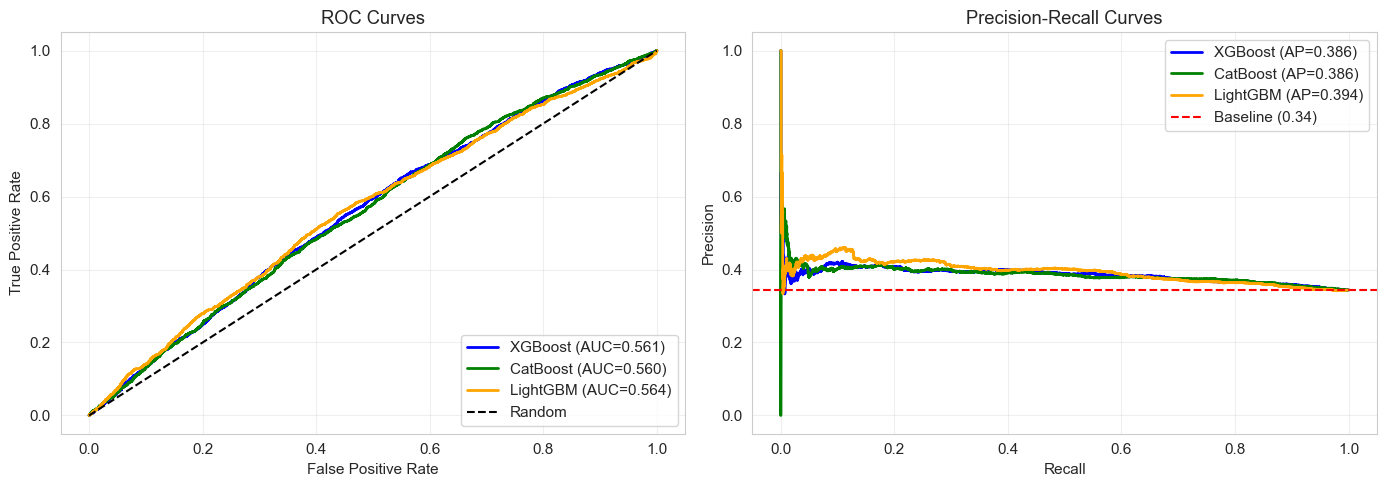

In [22]:
# Plot ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
colors = ['blue', 'green', 'orange']
for (name, data), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, data['probabilities'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={data['ROC-AUC']:.3f})", color=color, linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
for (name, data), color in zip(results.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, data['probabilities'])
    axes[1].plot(recall, precision, label=f"{name} (AP={data['Avg Precision']:.3f})", color=color, linewidth=2)

# Add baseline (random)
baseline = y_test.mean()
axes[1].axhline(baseline, color='red', linestyle='--', label=f'Baseline ({baseline:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Part 7: Confusion Matrix Analysis

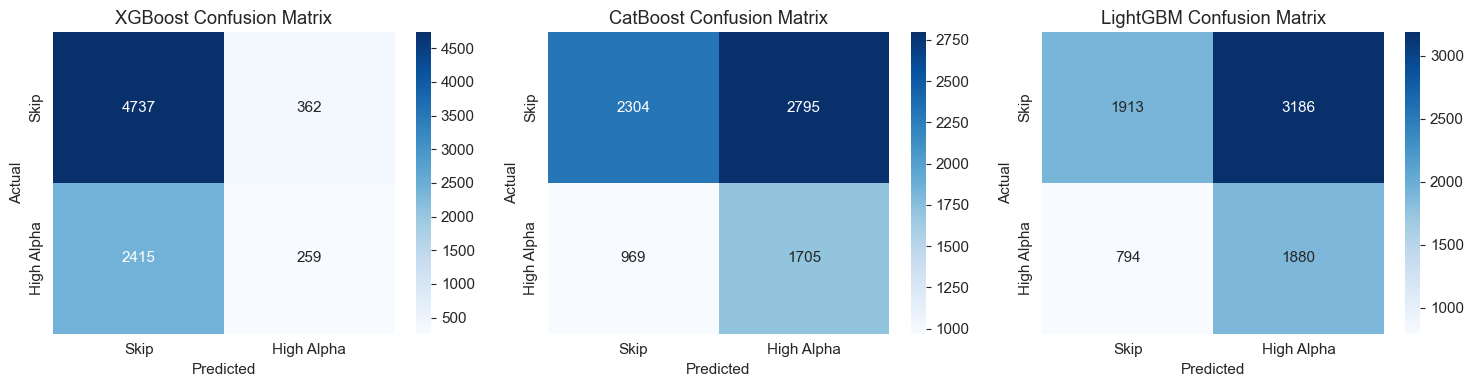

In [23]:
# Plot confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, data) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, data['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Skip', 'High Alpha'],
                yticklabels=['Skip', 'High Alpha'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{name} Confusion Matrix')

plt.tight_layout()
plt.show()

---
## Part 8: Probability Calibration Analysis

**Key Question:** Do predicted probabilities match actual outcomes?

e.g., When the model predicts 80% probability, do ~80% of those trades actually have alpha > 5%?

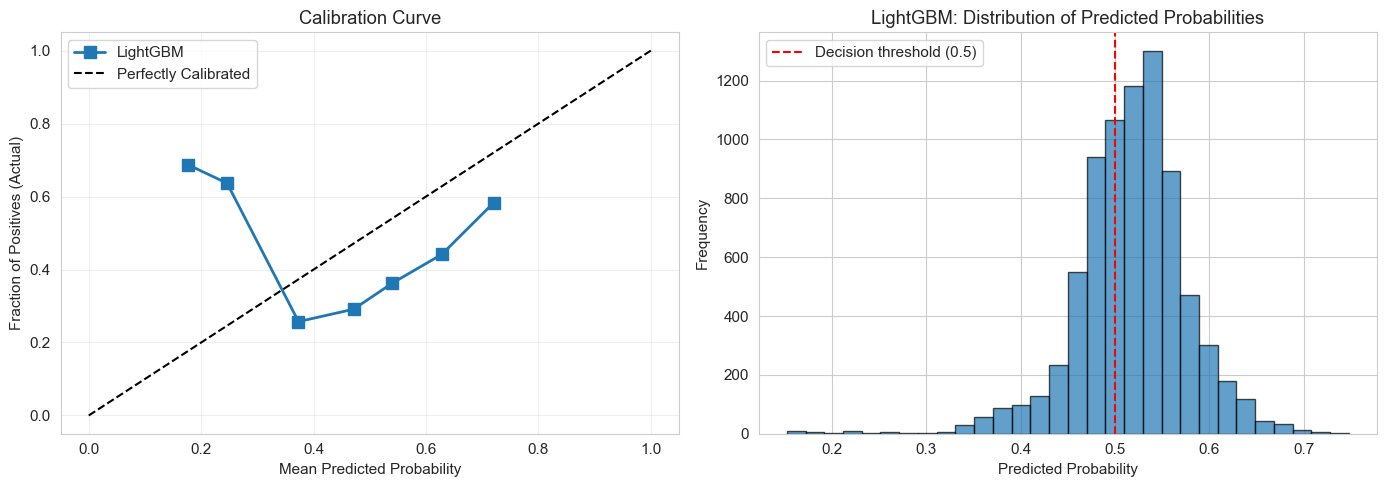

In [24]:
# Calibration curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calibration curve for best model
best_proba = results[best_model_name]['probabilities']
fraction_of_positives, mean_predicted_value = calibration_curve(y_test, best_proba, n_bins=10)

axes[0].plot(mean_predicted_value, fraction_of_positives, 's-', label=best_model_name, linewidth=2, markersize=8)
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives (Actual)')
axes[0].set_title('Calibration Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogram of predicted probabilities
axes[1].hist(best_proba, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(0.5, color='red', linestyle='--', label='Decision threshold (0.5)')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'{best_model_name}: Distribution of Predicted Probabilities')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Part 9: THE KEY METRIC - Average Alpha by Probability Bin

**This is the real test:** Do trades with higher predicted probability actually generate more alpha?

In [25]:
def analyze_alpha_by_probability(y_proba, actual_alpha, n_bins=10):
    """
    Analyze actual alpha returns by predicted probability bin.
    """
    df_analysis = pd.DataFrame({
        'probability': y_proba,
        'actual_alpha': actual_alpha
    })
    
    # Create probability bins
    df_analysis['prob_bin'] = pd.qcut(df_analysis['probability'], q=n_bins, duplicates='drop')
    
    # Calculate stats per bin
    bin_stats = df_analysis.groupby('prob_bin').agg({
        'probability': ['mean', 'count'],
        'actual_alpha': ['mean', 'median', 'std']
    }).round(4)
    
    bin_stats.columns = ['avg_prob', 'n_samples', 'avg_alpha', 'median_alpha', 'std_alpha']
    bin_stats = bin_stats.reset_index()
    
    return bin_stats

In [26]:
# Analyze for best model
best_proba = results[best_model_name]['probabilities']
actual_alpha = test_metadata['alpha_3m'].values

alpha_by_prob = analyze_alpha_by_probability(best_proba, actual_alpha, n_bins=10)

print(f" {best_model_name}: Average Alpha by Probability Decile")
print("=" * 70)
for _, row in alpha_by_prob.iterrows():
    print(f"   Prob: {row['avg_prob']:.2f} | n={int(row['n_samples']):4d} | "
          f"Avg Alpha: {row['avg_alpha']*100:+6.2f}% | Median: {row['median_alpha']*100:+6.2f}%")

 LightGBM: Average Alpha by Probability Decile
   Prob: 0.41 | n= 778 | Avg Alpha:  -8.26% | Median:  -6.11%
   Prob: 0.47 | n= 777 | Avg Alpha:  -3.87% | Median:  -3.88%
   Prob: 0.49 | n= 777 | Avg Alpha:  -0.74% | Median:  -2.68%
   Prob: 0.50 | n= 777 | Avg Alpha:  -1.01% | Median:  -4.51%
   Prob: 0.51 | n= 778 | Avg Alpha:  -1.96% | Median:  -5.23%
   Prob: 0.53 | n= 777 | Avg Alpha:  +0.95% | Median:  -2.72%
   Prob: 0.54 | n= 777 | Avg Alpha:  +6.37% | Median:  -0.61%
   Prob: 0.55 | n= 777 | Avg Alpha:  +3.41% | Median:  -1.42%
   Prob: 0.57 | n= 777 | Avg Alpha:  +6.61% | Median:  +0.70%
   Prob: 0.62 | n= 778 | Avg Alpha: +10.69% | Median:  +0.86%


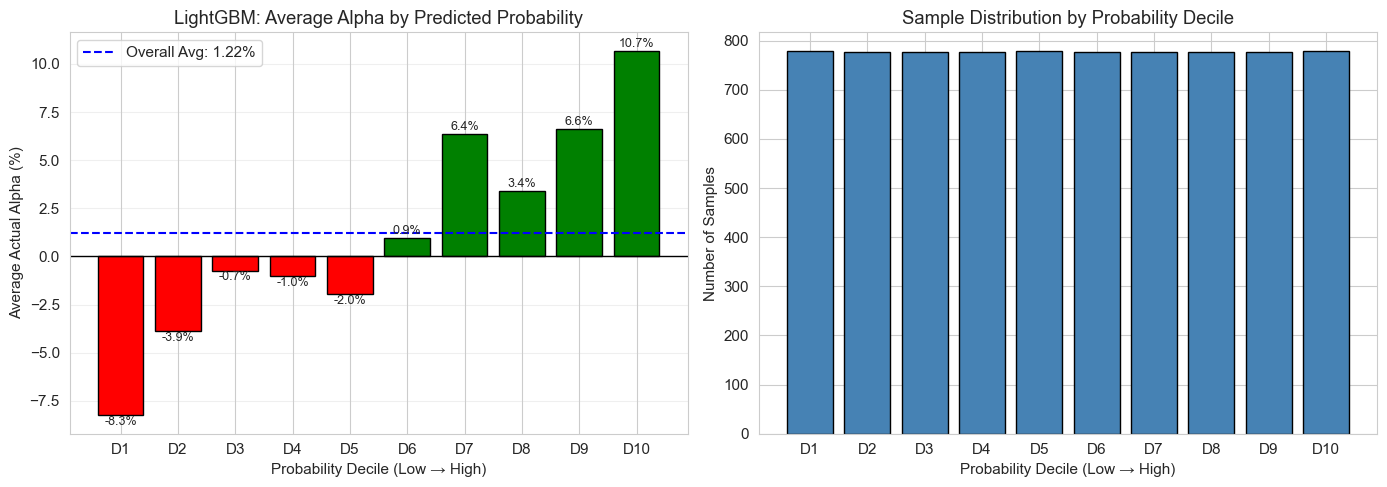

In [27]:
# Visualize Alpha by Probability Bin
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Average Alpha by Probability Bin
x = range(len(alpha_by_prob))
colors = ['red' if a < 0 else 'green' for a in alpha_by_prob['avg_alpha']]
bars = axes[0].bar(x, alpha_by_prob['avg_alpha'] * 100, color=colors, edgecolor='black')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].axhline(actual_alpha.mean() * 100, color='blue', linestyle='--', 
                label=f'Overall Avg: {actual_alpha.mean()*100:.2f}%')
axes[0].set_xlabel('Probability Decile (Low → High)')
axes[0].set_ylabel('Average Actual Alpha (%)')
axes[0].set_title(f'{best_model_name}: Average Alpha by Predicted Probability')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'D{i+1}' for i in range(len(alpha_by_prob))])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars, alpha_by_prob['avg_alpha']):
    ypos = bar.get_height() + 0.2 if val >= 0 else bar.get_height() - 0.5
    axes[0].text(bar.get_x() + bar.get_width()/2, ypos, 
                 f'{val*100:.1f}%', ha='center', fontsize=9)

# Plot 2: Sample count per bin
axes[1].bar(x, alpha_by_prob['n_samples'], color='steelblue', edgecolor='black')
axes[1].set_xlabel('Probability Decile (Low → High)')
axes[1].set_ylabel('Number of Samples')
axes[1].set_title('Sample Distribution by Probability Decile')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'D{i+1}' for i in range(len(alpha_by_prob))])

plt.tight_layout()
plt.show()

In [28]:
# Top Decile vs Bottom Decile comparison (THE KEY RESULT)
top_decile_alpha = alpha_by_prob.iloc[-1]['avg_alpha'] * 100
bottom_decile_alpha = alpha_by_prob.iloc[0]['avg_alpha'] * 100
overall_alpha = actual_alpha.mean() * 100

print("\n" + "=" * 60)
print(" KEY RESULT: Top vs Bottom Decile")
print("=" * 60)
print(f"   Top Decile (Highest Prob):    {top_decile_alpha:+.2f}%")
print(f"   Bottom Decile (Lowest Prob):  {bottom_decile_alpha:+.2f}%")
print(f"   Overall Average:              {overall_alpha:+.2f}%")
print(f"\n   Spread (Top - Bottom):        {top_decile_alpha - bottom_decile_alpha:+.2f}%")
print(f"   Top Decile vs Average:        {top_decile_alpha - overall_alpha:+.2f}%")

if top_decile_alpha > bottom_decile_alpha:
    print("\n    Model successfully ranks trades - higher probability → higher alpha!")
else:
    print("\n     Model ranking is inverted - needs investigation")


 KEY RESULT: Top vs Bottom Decile
   Top Decile (Highest Prob):    +10.69%
   Bottom Decile (Lowest Prob):  -8.26%
   Overall Average:              +1.22%

   Spread (Top - Bottom):        +18.95%
   Top Decile vs Average:        +9.47%

    Model successfully ranks trades - higher probability → higher alpha!


---
## Part 10: Backtest - Trading Strategy Based on Probability Threshold

In [29]:
# Prepare backtest data
backtest_df = test_metadata.copy()
backtest_df['predicted_prob'] = results[best_model_name]['probabilities']
backtest_df = backtest_df.sort_values('filing_date').reset_index(drop=True)

print(f"  Backtest Data:")
print(f"   Period: {backtest_df['filing_date'].min().date()} to {backtest_df['filing_date'].max().date()}")
print(f"   Total trades: {len(backtest_df):,}")

  Backtest Data:
   Period: 2024-01-02 to 2025-11-06
   Total trades: 7,773


In [30]:
def backtest_probability_strategy(df, prob_threshold=0.5, min_trades_per_period=5):
    """
    Backtest a strategy that only takes trades with probability above threshold.
    """
    df = df.copy()
    df['period'] = df['filing_date'].dt.to_period('W')
    
    period_results = []
    
    for period, group in df.groupby('period'):
        # Filter by probability threshold
        high_prob = group[group['predicted_prob'] >= prob_threshold]
        
        if len(high_prob) >= min_trades_per_period:
            avg_alpha = high_prob['alpha_3m'].mean()
            period_results.append({
                'period': period,
                'n_trades': len(high_prob),
                'avg_alpha': avg_alpha,
                'avg_prob': high_prob['predicted_prob'].mean()
            })
    
    result_df = pd.DataFrame(period_results)
    if len(result_df) > 0:
        result_df['period_date'] = result_df['period'].apply(lambda x: x.to_timestamp())
        result_df['cumulative_return'] = (1 + result_df['avg_alpha']).cumprod() - 1
    
    return result_df

In [31]:
# Run backtest with different thresholds
thresholds = [0.3, 0.4, 0.5, 0.6]
backtest_results = {}

print(" Backtest Results by Probability Threshold:")

for thresh in thresholds:
    bt = backtest_probability_strategy(backtest_df, prob_threshold=thresh, min_trades_per_period=3)
    if len(bt) > 0:
        backtest_results[thresh] = bt
        avg_alpha = bt['avg_alpha'].mean() * 100
        final_ret = bt['cumulative_return'].iloc[-1] * 100
        avg_trades = bt['n_trades'].mean()
        print(f"   Threshold ≥{thresh:.1f}: Avg Alpha={avg_alpha:+.2f}%, "
              f"Final Return={final_ret:+.1f}%, Avg Trades/Week={avg_trades:.1f}")

# Baseline (all trades)
baseline = backtest_probability_strategy(backtest_df, prob_threshold=0.0, min_trades_per_period=3)
backtest_results[0.0] = baseline
print(f"\n   Baseline (all): Avg Alpha={baseline['avg_alpha'].mean()*100:+.2f}%, "
      f"Final Return={baseline['cumulative_return'].iloc[-1]*100:+.1f}%")

 Backtest Results by Probability Threshold:
   Threshold ≥0.3: Avg Alpha=+1.71%, Final Return=+267.8%, Avg Trades/Week=79.7
   Threshold ≥0.4: Avg Alpha=+2.51%, Final Return=+643.7%, Avg Trades/Week=77.3
   Threshold ≥0.5: Avg Alpha=+4.81%, Final Return=+4943.5%, Avg Trades/Week=52.2
   Threshold ≥0.6: Avg Alpha=+12.30%, Final Return=+86515.9%, Avg Trades/Week=6.6

   Baseline (all): Avg Alpha=+1.74%, Final Return=+279.5%


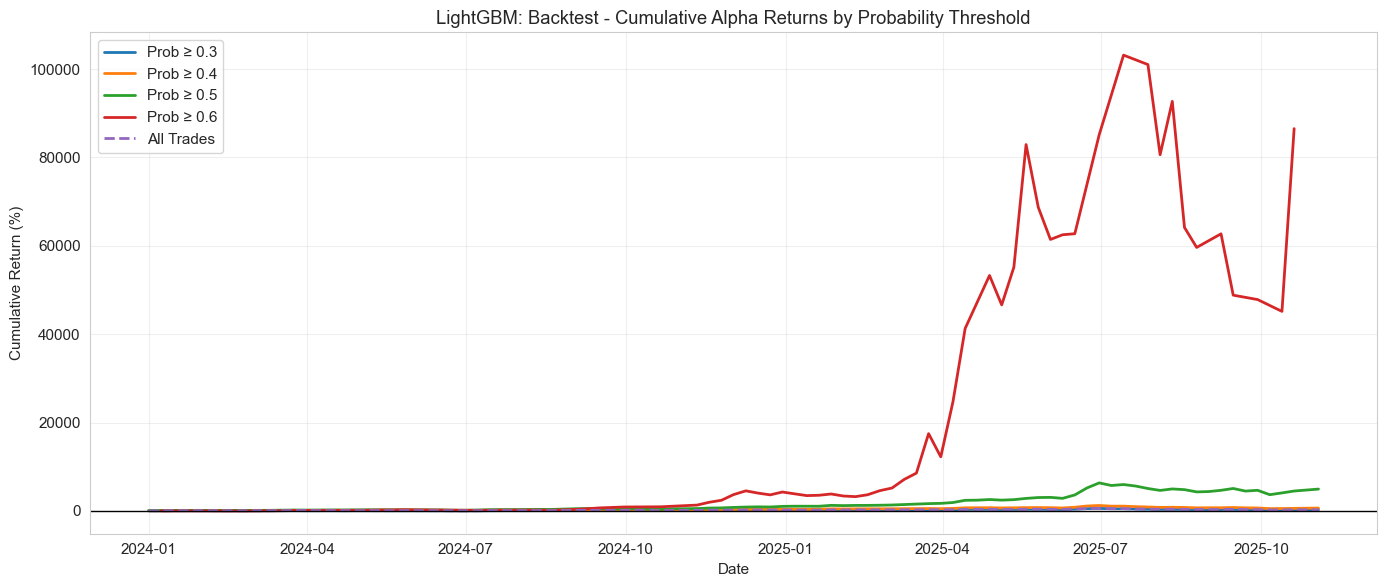

In [32]:
# Plot cumulative returns
fig, ax = plt.subplots(figsize=(14, 6))

colors = {'0.0': 'gray', '0.3': 'blue', '0.4': 'green', '0.5': 'orange', '0.6': 'red'}

for thresh, bt in backtest_results.items():
    label = 'All Trades' if thresh == 0.0 else f'Prob ≥ {thresh}'
    style = '--' if thresh == 0.0 else '-'
    ax.plot(bt['period_date'], bt['cumulative_return'] * 100, 
            label=label, linewidth=2, linestyle=style)

ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (%)')
ax.set_title(f'{best_model_name}: Backtest - Cumulative Alpha Returns by Probability Threshold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Part 11: SHAP Feature Importance

In [33]:
# SHAP analysis on best model
print(f"🔍 Computing SHAP values for {best_model_name}...")

# Get the appropriate model and data
if best_model_name == 'CatBoost':
    explainer = shap.TreeExplainer(cat_model)
    X_for_shap = X_test_cat.sample(n=min(2000, len(X_test_cat)), random_state=RANDOM_STATE)
elif best_model_name == 'LightGBM':
    explainer = shap.TreeExplainer(lgb_model)
    X_for_shap = X_test.sample(n=min(2000, len(X_test)), random_state=RANDOM_STATE)
else:
    explainer = shap.TreeExplainer(xgb_model)
    X_for_shap = X_test.sample(n=min(2000, len(X_test)), random_state=RANDOM_STATE)

shap_values = explainer.shap_values(X_for_shap)
print(f" SHAP values computed")

🔍 Computing SHAP values for LightGBM...
 SHAP values computed


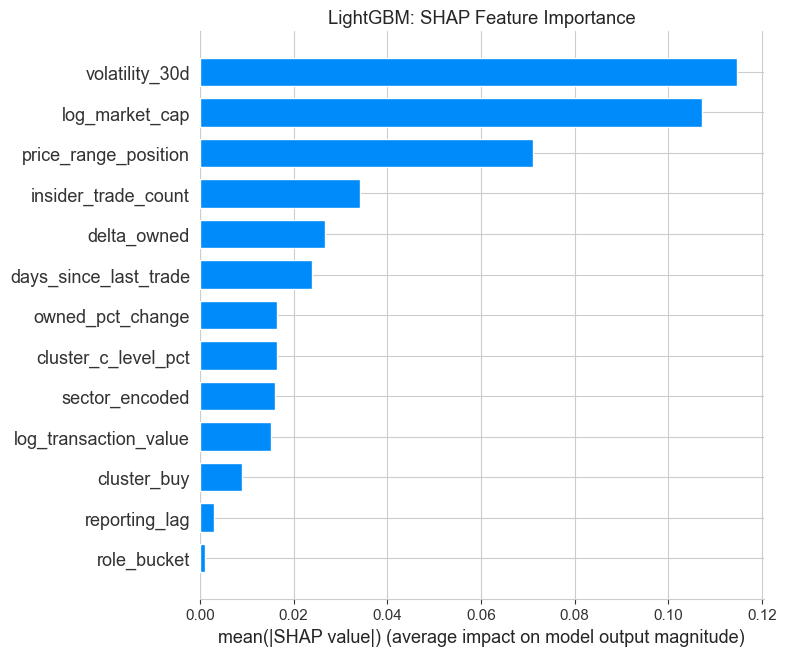

In [34]:
# SHAP Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_for_shap, plot_type="bar", show=False)
plt.title(f"{best_model_name}: SHAP Feature Importance")
plt.tight_layout()
plt.show()

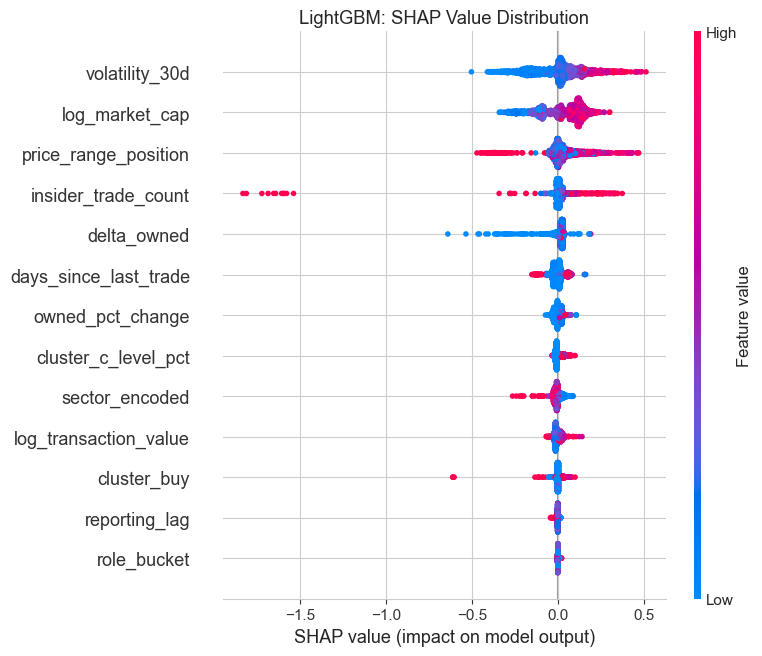

In [35]:
# Detailed SHAP plot
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_for_shap, show=False)
plt.title(f"{best_model_name}: SHAP Value Distribution")
plt.tight_layout()
plt.show()

---
## Part 12: Save Models and Summary

In [36]:
import joblib
import json

# Create output directory
model_output_dir = project_root / "src" / "models" / "saved_models"
model_output_dir.mkdir(parents=True, exist_ok=True)

# Save models
joblib.dump(xgb_model, model_output_dir / "xgb_classifier.joblib")
joblib.dump(lgb_model, model_output_dir / "lgb_classifier.joblib")
joblib.dump(cat_model, model_output_dir / "catboost_classifier.joblib")
joblib.dump(le_sector, model_output_dir / "sector_label_encoder.joblib")

# Save feature configuration
config = {
    'numerical_features': NUMERICAL_COLS,
    'categorical_features': CATEGORICAL_COLS,
    'feature_cols_encoded': FEATURE_COLS_ENCODED,
    'target_threshold': ALPHA_THRESHOLD,
    'best_model': best_model_name
}

with open(model_output_dir / "feature_config.json", 'w') as f:
    json.dump(config, f, indent=2)

print(f" Models saved to: {model_output_dir}")

 Models saved to: /Users/andres.latorre/Documents/Stock-Market-Movement-Prediction-Through-Insider-Trading-and-Multi-Source-Financial-Data/src/models/saved_models


In [37]:
# Final Summary
print("\n" + "=" * 80)
print(" FINAL SUMMARY - CLASSIFICATION APPROACH")

print(f"\n Dataset:")
print(f"   Train: {len(df_train):,} samples (2018-2023)")
print(f"   Test:  {len(df_test):,} samples (2024+)")
print(f"   Features: {len(FEATURE_COLS_ENCODED)}")
print(f"   Target: alpha_3m > {ALPHA_THRESHOLD*100:.0f}% (Class 1)")

print(f"\n Best Model: {best_model_name}")
print(f"   ROC-AUC: {results[best_model_name]['ROC-AUC']:.4f}")
print(f"   Avg Precision: {results[best_model_name]['Avg Precision']:.4f}")

print(f"\n Key Insight: Alpha by Probability Decile")
print(f"   Top Decile Avg Alpha:    {top_decile_alpha:+.2f}%")
print(f"   Bottom Decile Avg Alpha: {bottom_decile_alpha:+.2f}%")
print(f"   Spread:                  {top_decile_alpha - bottom_decile_alpha:+.2f}%")

if len(backtest_results) > 0 and 0.5 in backtest_results:
    bt_05 = backtest_results[0.5]
    print(f"\n💰 Backtest (Prob ≥ 0.5):")
    print(f"   Avg Weekly Alpha: {bt_05['avg_alpha'].mean()*100:+.2f}%")
    print(f"   Cumulative Return: {bt_05['cumulative_return'].iloc[-1]*100:+.1f}%")

print("\n" + "=" * 80)


 FINAL SUMMARY - CLASSIFICATION APPROACH

 Dataset:
   Train: 31,620 samples (2018-2023)
   Test:  7,773 samples (2024+)
   Features: 13
   Target: alpha_3m > 5% (Class 1)

 Best Model: LightGBM
   ROC-AUC: 0.5640
   Avg Precision: 0.3943

 Key Insight: Alpha by Probability Decile
   Top Decile Avg Alpha:    +10.69%
   Bottom Decile Avg Alpha: -8.26%
   Spread:                  +18.95%

💰 Backtest (Prob ≥ 0.5):
   Avg Weekly Alpha: +4.81%
   Cumulative Return: +4943.5%



---
## 🎯 Conclusions

### Why Classification Works Better
1. **Robust to outliers**: Extreme returns (e.g., +500%) don't break the model
2. **Better signal extraction**: The model focuses on patterns that predict "good" vs "bad" trades
3. **Actionable outputs**: Probability scores let us rank and filter trades

### How to Use This Model
1. Score new insider trades with the classifier
2. Filter for trades with probability ≥ 0.5 (or your chosen threshold)
3. The top-decile trades should outperform the baseline

### Next Steps
1. **Ensemble models** for more robust predictions
2. **Adjust threshold** based on desired precision/recall tradeoff
3. **Deploy** for real-time scoring of SEC filings